## Final Lab
Kyle Vogel, Alex Elias, Matt Benson
\
DS 3022

---
### Primary Question: Can in-game shooting efficiency, rebounding, and playmaking, predict the outcome of an NBA game?

- Model 1: Baseline logistic regression using FG%, Reb, Ass with the lbfgs solver Model 
- Model 2: Using same features, swapping Saga and Liblinear solvers instead 
- Model 3: Add balanced class weights and cross-validation

With the NBA championship in our presence, we were curious to explore which in-game factors are most important when it comes to predicting the outcome of a game (aka, who wins).To ensure accuracy and reproducibility, were using a dataset that covers all NBA games from 2004 to December of 2020. This dataset contains 26,651 Nba games worth of in-game statistics. Each row within the dataset is a specific game, with respect to its corresponding performance metrics such as: field goal percentage, free throw percentage, three-point percentage, assists, rebounds, and total points scored.(Just a few) 

Our target variable for this project will be Home Team Wins. A binary column will represent either a 1, if the home team won, or a 0, indicating the away team won. Of all games in the dataset, the home team won approximately 59% of the time, which hints that our classes are slightly imbalanced.

For our model, we’ll be focusing on three main feature groups to fuel our predictions: Field goal percentage, rebounds, and assists, giving us 6 total predictors (3 home and 3 away)

---

## Part 1: EDA and Data Cleaning

In [7]:
# First we import our libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [8]:
# Let's open up the dataset and see what columns we're working with

df = pd.read_csv('games.csv')
df.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [9]:
# Let's get an even more detailed look at the dataset we're working with and all the various components of it

print(df.describe())
print(df.info())
print(df.shape)

            GAME_ID  HOME_TEAM_ID  VISITOR_TEAM_ID        SEASON  \
count  2.665100e+04  2.665100e+04     2.665100e+04  26651.000000   
mean   2.175487e+07  1.610613e+09     1.610613e+09   2012.113879   
std    5.570189e+06  8.638670e+00     8.659299e+00      5.587031   
min    1.030000e+07  1.610613e+09     1.610613e+09   2003.000000   
25%    2.070001e+07  1.610613e+09     1.610613e+09   2007.000000   
50%    2.120076e+07  1.610613e+09     1.610613e+09   2012.000000   
75%    2.180005e+07  1.610613e+09     1.610613e+09   2017.000000   
max    5.210021e+07  1.610613e+09     1.610613e+09   2022.000000   

       TEAM_ID_home      PTS_home   FG_PCT_home   FT_PCT_home  FG3_PCT_home  \
count  2.665100e+04  26552.000000  26552.000000  26552.000000  26552.000000   
mean   1.610613e+09    103.455898      0.460735      0.760377      0.356023   
std    8.638670e+00     13.283370      0.056676      0.100677      0.111164   
min    1.610613e+09     36.000000      0.250000      0.143000      0.00

In [10]:
# How often does the Home Team actually win?
df['HOME_TEAM_WINS'].value_counts(normalize=True)

HOME_TEAM_WINS
1    0.587032
0    0.412968
Name: proportion, dtype: float64

Wow, so here we can see that the home team actually wins 58.7% of the time. Interesting

In [11]:
# Let's see if there is are any columns that have missing values
print(df.isnull().sum())

GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64


In [12]:
# Now let's drop the columns that have leakage to the question we are trying to solve. We don't want the model to be able to perfectly predict the dataset, so we drop these
df = df.drop(columns=['PTS_home', 'PTS_away', 'GAME_ID', 'GAME_DATE_EST',
                       'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID',
                       'TEAM_ID_home', 'TEAM_ID_away', 'SEASON'], errors='ignore')

# Let's also drop any remaining columns that have missing values in them
df = df.dropna()

print(df.shape)

(26552, 11)


In [13]:
# Now we can also go ahead and set our X and Y variables, and put the numerical/categorical features in their own respective lists

X = df.drop(columns=['HOME_TEAM_WINS'])
y = df['HOME_TEAM_WINS']

num_feat = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical features:", num_feat)

Numerical features: ['FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away']


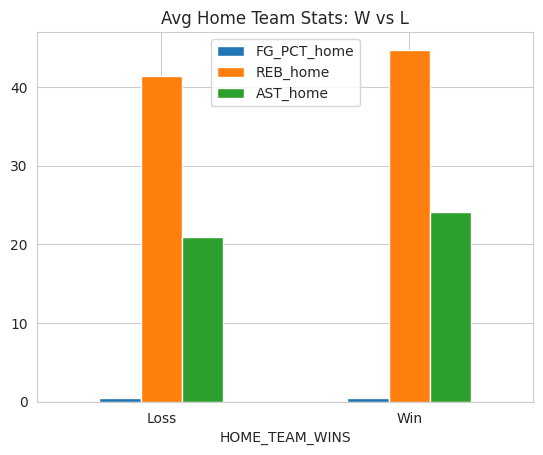

In [ ]:
# To see if our features truly separate winners from losers, we show a grouped bar chart comparing our three features.
# The idea behind this plot is the variety of bars. Since they are of differnt ranges (low, medium, high), they justify our feature choices.
features = ['FG_PCT_home', 'REB_home', 'AST_home']
df.groupby('HOME_TEAM_WINS')[features].mean().plot(kind='bar')
plt.title("Avg Home Team Stats: W vs L")
plt.xticks([0,1], ['Loss', 'Win'], rotation=0)
plt.show()

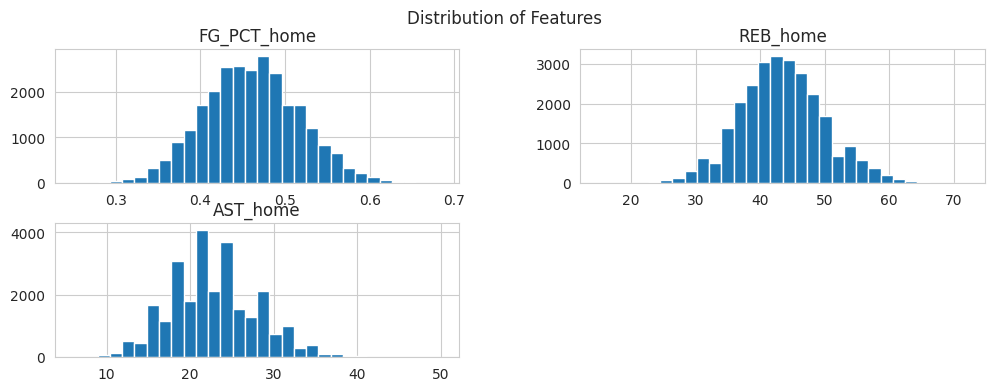

In [17]:
# For our second plot, a histogram will tell us whether or not our data is skewed or has outliers.
# As you can see, our data is not skewed
df[['FG_PCT_home', 'REB_home', 'AST_home']].hist(bins=30, figsize=(12,4))
plt.suptitle('Distribution of Features')
plt.show()

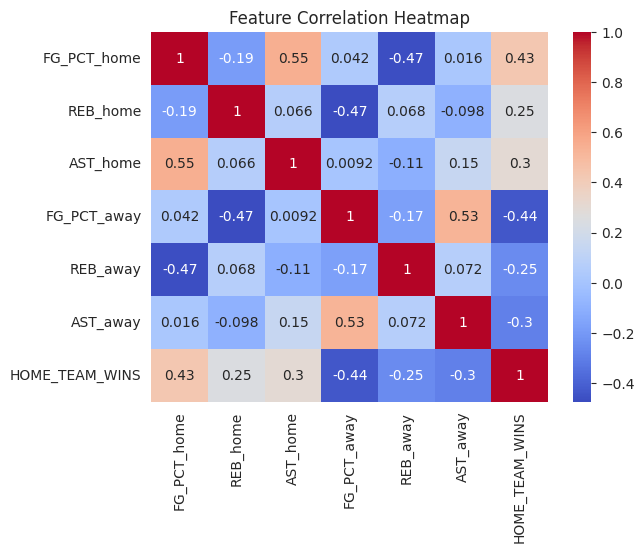

In [ ]:
# Third plot
# Feature correlation heatmap determining if any mullticolinearity between features exists
# Now we can visually locate the strongest indicators of feature collaboration
cols = ['FG_PCT_home','REB_home','AST_home','FG_PCT_away','REB_away','AST_away','HOME_TEAM_WINS']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Model 1

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), num_feat)
])

pipeline1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(solver='lbfgs', max_iter=1000))
])

pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

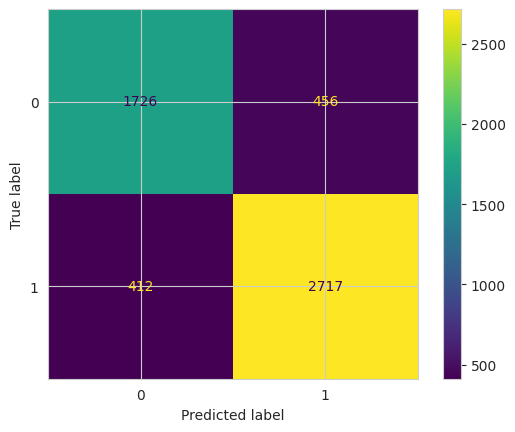

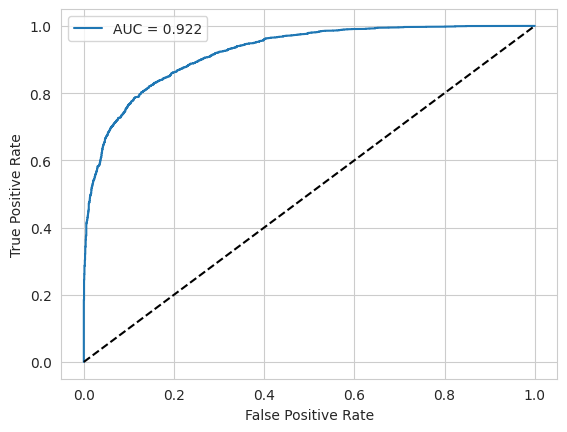

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2182
           1       0.86      0.87      0.86      3129

    accuracy                           0.84      5311
   macro avg       0.83      0.83      0.83      5311
weighted avg       0.84      0.84      0.84      5311



In [21]:
y_pred = pipeline1.predict(X_test)
y_prob = pipeline1.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# ROC/AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print(classification_report(y_test, y_pred))